In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import requests
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/v1/fbref/Big5 2024-2025 std.csv')
df.drop(columns=['Rk', 'Born', 'MP', 'Starts', 'Min', '90s', 'Matches'], inplace=True)

In [3]:
df = df[df['Pos'] == 'FW']  # Only take data for 'FW'

In [4]:
df_temp = pd.read_csv('../../data/v1/fbref/Big5 2024-2025 Playing Time.csv')
df_temp.drop(columns=['Rk', 'Player', 'Nation', 'Pos', 'Comp', 'Age', 'Born', 'Matches'], inplace=True)  # Drop duplicates before merging
df = pd.merge(df, df_temp, on=['-9999', 'Squad'], how='left')  # Also merge on Squad since a player can work for two clubs in a season

In [5]:
df_temp = pd.read_csv('../../data/v1/fbref/Big5 2024-2025 Shooting.csv')
print(df_temp.columns)
df_temp.drop(columns=['Rk', 'Player', 'Nation', 'Pos', 'Comp', 'Age', 'Born', '90s', 'Matches', 'Gls', 'PK', 'PKatt'], inplace=True)  # Drop duplicates before merging
df = pd.merge(df, df_temp, on=['-9999', 'Squad'], how='left')  # Also merge on Squad since a player can work for two clubs in a season

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s',
       'Gls', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK',
       'PKatt', 'Matches', '-9999'],
      dtype='str')


In [6]:
df_temp = pd.read_csv('../../data/v1/fbref/Big5 2024-2025 Miscellaneous.csv')
print(df_temp.columns)
df_temp.drop(columns=['Rk', 'Player', 'Nation', 'Pos', 'Comp', 'Age', 'Born', '90s', 'Matches'], inplace=True)  # Drop duplicates before merging
df = pd.merge(df, df_temp, on=['-9999', 'Squad'], how='left')  # Also merge on Squad since a player can work for two clubs in a season

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', '90s',
       'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW',
       'PKwon', 'PKcon', 'OG', 'Matches', '-9999'],
      dtype='str')


In [7]:
df.rename(columns={"-9999": "fbref_id"}, inplace=True)

In [8]:
df_temp = pd.read_csv('../../data/v1/id_pair.csv')
df = pd.merge(df, df_temp, on='fbref_id', how='left')

In [9]:
df.drop(columns=['PKwon', 'PKcon'], inplace=True)  # Drop unrelated columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 55 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            363 non-null    str    
 1   Nation            362 non-null    str    
 2   Pos               363 non-null    str    
 3   Squad             363 non-null    str    
 4   Comp              363 non-null    str    
 5   Age               363 non-null    float64
 6   Gls               363 non-null    int64  
 7   Ast               363 non-null    int64  
 8   G+A               363 non-null    int64  
 9   G-PK              363 non-null    int64  
 10  PK                363 non-null    int64  
 11  PKatt             363 non-null    int64  
 12  CrdY_x            363 non-null    int64  
 13  CrdR_x            363 non-null    int64  
 14  Gls p90           363 non-null    float64
 15  Ast p90           363 non-null    float64
 16  G+A p90           363 non-null    float64
 17  G-PK p90

Player, Nation, Pos, Squad, fbref_id, transfermarkt_id are dropped when trainning

In [10]:
df = df[df['Min'] > 500]
df.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 361
Data columns (total 55 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            180 non-null    str    
 1   Nation            180 non-null    str    
 2   Pos               180 non-null    str    
 3   Squad             180 non-null    str    
 4   Comp              180 non-null    str    
 5   Age               180 non-null    float64
 6   Gls               180 non-null    int64  
 7   Ast               180 non-null    int64  
 8   G+A               180 non-null    int64  
 9   G-PK              180 non-null    int64  
 10  PK                180 non-null    int64  
 11  PKatt             180 non-null    int64  
 12  CrdY_x            180 non-null    int64  
 13  CrdR_x            180 non-null    int64  
 14  Gls p90           180 non-null    float64
 15  Ast p90           180 non-null    float64
 16  G+A p90           180 non-null    float64
 17  G-PK p90     

In [11]:
null_rows = df[df['transfermarkt_id'].isnull()]
print(null_rows)

              Player  Nation Pos       Squad        Comp   Age  Gls  Ast  G+A  \
16      Marcos André  br BRA  FW  Valladolid  es La Liga  27.0    1    2    3   
21  Marko Arnautović  at AUT  FW       Inter  it Serie A  35.0    4    2    6   

    G-PK  PK  PKatt  CrdY_x  CrdR_x  Gls p90  Ast p90  G+A p90  G-PK p90  \
16     1   0      0       5       0     0.08     0.15     0.23      0.08   
21     4   0      0       1       0     0.66     0.33     0.98      0.66   

    G+A-PK p90  fbref_id  MP     Min  Mn/MP  Min%   90s  Starts  Mn/Start  \
16        0.23  ae86d473  22  1188.0   54.0  34.7  13.2      14      75.0   
21        0.98    459419  18   549.0   31.0  16.1   6.1       5      69.0   

    Compl  Subs  Mn/Sub  unSub   PPM   onG  onGA   +/-  +/-90  On-Off  Sh  \
16      2     8    17.0     13  0.41  11.0  32.0 -21.0  -1.59    0.14  22   
21      1    13    16.0     20  2.06  12.0   9.0   3.0   0.49   -0.79  14   

    SoT  SoT%  Sh/90  SoT/90  G/Sh  G/SoT  CrdY_y  CrdR_y  2Crd

In [12]:
df.loc[df['fbref_id'] == 'ae86d473', 'transfermarkt_id'] = 481084
df.loc[df['fbref_id'] == '459419', 'transfermarkt_id'] = 41384
df.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 361
Data columns (total 55 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            180 non-null    str    
 1   Nation            180 non-null    str    
 2   Pos               180 non-null    str    
 3   Squad             180 non-null    str    
 4   Comp              180 non-null    str    
 5   Age               180 non-null    float64
 6   Gls               180 non-null    int64  
 7   Ast               180 non-null    int64  
 8   G+A               180 non-null    int64  
 9   G-PK              180 non-null    int64  
 10  PK                180 non-null    int64  
 11  PKatt             180 non-null    int64  
 12  CrdY_x            180 non-null    int64  
 13  CrdR_x            180 non-null    int64  
 14  Gls p90           180 non-null    float64
 15  Ast p90           180 non-null    float64
 16  G+A p90           180 non-null    float64
 17  G-PK p90     

In [13]:
df.head(10)

,Player,Nation,Pos,Squad,Comp,Age,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY_x,CrdR_x,Gls p90,Ast p90,G+A p90,G-PK p90,G+A-PK p90,fbref_id,MP,Min,Mn/MP,Min%,90s,Starts,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,CrdY_y,CrdR_y,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,transfermarkt_id
1,Matthis Abline,fr FRA,FW,Nantes,fr Ligue 1,21.0,9,2,11,8,1,1,3,0,0.29,0.07,0.36,0.26,0.33,0e46fa2f,34,2768.0,81.0,90.5,30.8,33,83.0,12,1,23.0,0,1.06,34.0,42.0,-8.0,-0.26,1.28,73,27,37.0,2.37,0.88,0.12,0.33,3,0,0,34,55,5,31,6,4,0,659543.0
3,Tammy Abraham,eng ENG,FW,Milan,it Serie A,26.0,3,4,7,2,1,2,1,0,0.23,0.30,0.53,0.15,0.46,f586779e,28,1183.0,42.0,34.6,13.1,12,70.0,2,16,22.0,6,1.75,27.0,14.0,13.0,0.99,0.79,28,13,46.4,2.13,0.99,0.11,0.23,1,0,0,23,12,6,3,2,11,0,331726.0
4,Akor Adams,ng NGA,FW,Montpellier,fr Ligue 1,24.0,3,1,4,3,0,0,2,0,0.25,0.08,0.33,0.25,0.33,2ccd39ed,15,1075.0,72.0,35.1,11.9,13,79.0,7,2,22.0,1,0.53,12.0,29.0,-17.0,-1.42,0.35,26,12,46.2,2.18,1.00,0.12,0.25,2,0,0,17,8,16,5,1,3,0,607034.0
6,Ché Adams,sct SCO,FW,Torino,it Serie A,28.0,9,3,12,9,0,1,2,0,0.31,0.10,0.41,0.31,0.41,f2bf1b0f,36,2652.0,74.0,77.5,29.5,30,82.0,20,6,33.0,1,1.14,31.0,36.0,-5.0,-0.17,-0.05,64,26,40.6,2.17,0.88,0.14,0.35,2,0,0,29,40,23,10,1,6,0,346779.0
7,Junior Adamu,at AUT,FW,Freiburg,de Bundesliga,23.0,2,2,4,2,0,0,5,1,0.12,0.12,0.23,0.12,0.23,82e12fe7,25,1545.0,62.0,50.5,17.2,19,75.0,4,6,20.0,5,1.40,20.0,29.0,-9.0,-0.52,-0.82,37,12,32.4,2.16,0.70,0.05,0.17,5,1,0,37,22,17,5,11,3,0,452477.0
10,Ludovic Ajorque,fr FRA,FW,Brest,fr Ligue 1,30.0,13,2,15,13,0,1,5,0,0.47,0.07,0.54,0.47,0.54,462475ed,31,2495.0,80.0,81.5,27.7,29,84.0,16,2,28.0,0,1.48,44.0,47.0,-3.0,-0.11,0.53,54,27,50.0,1.95,0.97,0.24,0.48,5,0,0,61,26,11,7,5,18,0,283994.0
12,Chuba Akpom,eng ENG,FW,Lille,fr Ligue 1,28.0,3,1,4,2,1,2,0,0,0.42,0.14,0.56,0.28,0.42,e2b384d2,14,639.0,46.0,20.9,7.1,6,69.0,0,8,28.0,0,1.79,10.0,9.0,1.0,0.14,-0.42,20,11,55.0,2.82,1.55,0.15,0.27,0,0,0,11,15,2,1,0,5,0,197642.0
15,Julián Álvarez,ar ARG,FW,Atlético Madrid,es La Liga,24.0,17,4,21,13,4,4,5,0,0.61,0.14,0.75,0.47,0.61,15ab5a2b,37,2509.0,68.0,73.4,27.9,30,77.0,12,7,29.0,0,1.97,47.0,17.0,30.0,1.08,0.29,73,40,54.8,2.62,1.43,0.23,0.43,5,0,0,26,9,9,69,2,17,0,576024.0
16,Marcos André,br BRA,FW,Valladolid,es La Liga,27.0,1,2,3,1,0,0,5,0,0.08,0.15,0.23,0.08,0.23,ae86d473,22,1188.0,54.0,34.7,13.2,14,75.0,2,8,17.0,13,0.41,11.0,32.0,-21.0,-1.59,0.14,22,2,9.1,1.67,0.15,0.05,0.50,5,0,0,12,28,5,1,3,6,0,481084.0
19,Michail Antonio,jm JAM,FW,West Ham,eng Premier League,34.0,1,1,2,1,0,0,1,0,0.11,0.11,0.22,0.11,0.22,ac05f970,14,836.0,60.0,24.4,9.3,11,66.0,0,3,37.0,0,1.07,13.0,18.0,-5.0,-0.54,-0.16,19,4,21.1,2.05,0.43,0.05,0.25,1,0,0,12,7,4,25,0,2,0,104124.0


In [14]:
for row in df.itertuples():
    # Access attributes using row.ColumnName
    transfermarkt_id = row.transfermarkt_id
    url = f'https://tmapi.transfermarkt.technology/player/{transfermarkt_id}/market-value-history'
    page = requests.get(url)

    data = page.json()

    list = data.get("data").get("history")
    position = -1
    for index, record in enumerate(list):
        if (list[index].get("seasonId") == 2024):
            position = index - 1
            break
    if (position != -1):
        df.at[row.Index, 'value_24'] = list[position].get("marketValue").get("value")

    list = data.get("data").get("history")
    position = -1
    for index, record in enumerate(list):
        if (list[index].get("seasonId") == 2025):
            position = index - 1
            break
    if (position != -1):
        df.at[row.Index, 'value_25'] = list[position].get("marketValue").get("value")

In [15]:
df.head(10)

,Player,Nation,Pos,Squad,Comp,Age,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY_x,CrdR_x,Gls p90,Ast p90,G+A p90,G-PK p90,G+A-PK p90,fbref_id,MP,Min,Mn/MP,Min%,90s,Starts,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,CrdY_y,CrdR_y,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG,transfermarkt_id,value_24,value_25
1,Matthis Abline,fr FRA,FW,Nantes,fr Ligue 1,21.0,9,2,11,8,1,1,3,0,0.29,0.07,0.36,0.26,0.33,0e46fa2f,34,2768.0,81.0,90.5,30.8,33,83.0,12,1,23.0,0,1.06,34.0,42.0,-8.0,-0.26,1.28,73,27,37.0,2.37,0.88,0.12,0.33,3,0,0,34,55,5,31,6,4,0,659543.0,6000000.0,18000000.0
3,Tammy Abraham,eng ENG,FW,Milan,it Serie A,26.0,3,4,7,2,1,2,1,0,0.23,0.30,0.53,0.15,0.46,f586779e,28,1183.0,42.0,34.6,13.1,12,70.0,2,16,22.0,6,1.75,27.0,14.0,13.0,0.99,0.79,28,13,46.4,2.13,0.99,0.11,0.23,1,0,0,23,12,6,3,2,11,0,331726.0,30000000.0,15000000.0
4,Akor Adams,ng NGA,FW,Montpellier,fr Ligue 1,24.0,3,1,4,3,0,0,2,0,0.25,0.08,0.33,0.25,0.33,2ccd39ed,15,1075.0,72.0,35.1,11.9,13,79.0,7,2,22.0,1,0.53,12.0,29.0,-17.0,-1.42,0.35,26,12,46.2,2.18,1.00,0.12,0.25,2,0,0,17,8,16,5,1,3,0,607034.0,10000000.0,5000000.0
6,Ché Adams,sct SCO,FW,Torino,it Serie A,28.0,9,3,12,9,0,1,2,0,0.31,0.10,0.41,0.31,0.41,f2bf1b0f,36,2652.0,74.0,77.5,29.5,30,82.0,20,6,33.0,1,1.14,31.0,36.0,-5.0,-0.17,-0.05,64,26,40.6,2.17,0.88,0.14,0.35,2,0,0,29,40,23,10,1,6,0,346779.0,15000000.0,15000000.0
7,Junior Adamu,at AUT,FW,Freiburg,de Bundesliga,23.0,2,2,4,2,0,0,5,1,0.12,0.12,0.23,0.12,0.23,82e12fe7,25,1545.0,62.0,50.5,17.2,19,75.0,4,6,20.0,5,1.40,20.0,29.0,-9.0,-0.52,-0.82,37,12,32.4,2.16,0.70,0.05,0.17,5,1,0,37,22,17,5,11,3,0,452477.0,4000000.0,5000000.0
10,Ludovic Ajorque,fr FRA,FW,Brest,fr Ligue 1,30.0,13,2,15,13,0,1,5,0,0.47,0.07,0.54,0.47,0.54,462475ed,31,2495.0,80.0,81.5,27.7,29,84.0,16,2,28.0,0,1.48,44.0,47.0,-3.0,-0.11,0.53,54,27,50.0,1.95,0.97,0.24,0.48,5,0,0,61,26,11,7,5,18,0,283994.0,3000000.0,4000000.0
12,Chuba Akpom,eng ENG,FW,Lille,fr Ligue 1,28.0,3,1,4,2,1,2,0,0,0.42,0.14,0.56,0.28,0.42,e2b384d2,14,639.0,46.0,20.9,7.1,6,69.0,0,8,28.0,0,1.79,10.0,9.0,1.0,0.14,-0.42,20,11,55.0,2.82,1.55,0.15,0.27,0,0,0,11,15,2,1,0,5,0,197642.0,12000000.0,7000000.0
15,Julián Álvarez,ar ARG,FW,Atlético Madrid,es La Liga,24.0,17,4,21,13,4,4,5,0,0.61,0.14,0.75,0.47,0.61,15ab5a2b,37,2509.0,68.0,73.4,27.9,30,77.0,12,7,29.0,0,1.97,47.0,17.0,30.0,1.08,0.29,73,40,54.8,2.62,1.43,0.23,0.43,5,0,0,26,9,9,69,2,17,0,576024.0,90000000.0,100000000.0
16,Marcos André,br BRA,FW,Valladolid,es La Liga,27.0,1,2,3,1,0,0,5,0,0.08,0.15,0.23,0.08,0.23,ae86d473,22,1188.0,54.0,34.7,13.2,14,75.0,2,8,17.0,13,0.41,11.0,32.0,-21.0,-1.59,0.14,22,2,9.1,1.67,0.15,0.05,0.50,5,0,0,12,28,5,1,3,6,0,481084.0,2000000.0,1000000.0
19,Michail Antonio,jm JAM,FW,West Ham,eng Premier League,34.0,1,1,2,1,0,0,1,0,0.11,0.11,0.22,0.11,0.22,ac05f970,14,836.0,60.0,24.4,9.3,11,66.0,0,3,37.0,0,1.07,13.0,18.0,-5.0,-0.54,-0.16,19,4,21.1,2.05,0.43,0.05,0.25,1,0,0,12,7,4,25,0,2,0,104124.0,4000000.0,500000.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 361
Data columns (total 57 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            180 non-null    str    
 1   Nation            180 non-null    str    
 2   Pos               180 non-null    str    
 3   Squad             180 non-null    str    
 4   Comp              180 non-null    str    
 5   Age               180 non-null    float64
 6   Gls               180 non-null    int64  
 7   Ast               180 non-null    int64  
 8   G+A               180 non-null    int64  
 9   G-PK              180 non-null    int64  
 10  PK                180 non-null    int64  
 11  PKatt             180 non-null    int64  
 12  CrdY_x            180 non-null    int64  
 13  CrdR_x            180 non-null    int64  
 14  Gls p90           180 non-null    float64
 15  Ast p90           180 non-null    float64
 16  G+A p90           180 non-null    float64
 17  G-PK p90     

In [17]:
duplicate_rows = df[df['transfermarkt_id'].duplicated(keep=False)]
print(duplicate_rows)

                  Player  Nation Pos       Squad        Comp   Age  Gls  Ast  \
99   Anastasios Douvikas  gr GRE  FW        Como  it Serie A  24.0    2    2   
100  Anastasios Douvikas  gr GRE  FW  Celta Vigo  es La Liga  24.0    3    1   

     G+A  G-PK  PK  PKatt  CrdY_x  CrdR_x  Gls p90  Ast p90  G+A p90  \
99     4     2   0      0       1       0     0.31     0.31     0.62   
100    4     3   0      0       2       0     0.39     0.13     0.51   

     G-PK p90  G+A-PK p90  fbref_id  MP    Min  Mn/MP  Min%  90s  Starts  \
99       0.31        0.62  853ca71c  13  580.0   45.0  17.0  6.4       6   
100      0.39        0.51  853ca71c  20  700.0   35.0  20.5  7.8       6   

     Mn/Start  Compl  Subs  Mn/Sub  unSub   PPM   onG  onGA  +/-  +/-90  \
99       72.0      2     7    21.0      1  1.85  10.0   8.0  2.0   0.31   
100      66.0      0    14    22.0      2  1.25  14.0  13.0  1.0   0.13   

     On-Off  Sh  SoT  SoT%  Sh/90  SoT/90  G/Sh  G/SoT  CrdY_y  CrdR_y  2CrdY  \
99    

In [18]:
print(df[df['value_25'].isnull()])

             Player  Nation Pos        Squad                Comp   Age  Gls  \
89      Andy Delort  dz ALG  FW  Montpellier          fr Ligue 1  32.0    0   
165      Diogo Jota  pt POR  FW    Liverpool  eng Premier League  27.0    6   
246  Ibrahima Niane  sn SEN  FW       Angers          fr Ligue 1  25.0    3   

     Ast  G+A  G-PK  PK  PKatt  CrdY_x  CrdR_x  Gls p90  Ast p90  G+A p90  \
89     0    0     0   0      0       1       0     0.00     0.00     0.00   
165    3    9     6   0      0       2       0     0.45     0.23     0.68   
246    1    4     2   1      1       0       0     0.29     0.10     0.38   

     G-PK p90  G+A-PK p90  fbref_id  MP     Min  Mn/MP  Min%   90s  Starts  \
89       0.00        0.00  d33c706e   9   607.0   67.0  19.8   6.7       8   
165      0.45        0.68  178ae8f8  26  1196.0   46.0  35.0  13.3      14   
246      0.19        0.29  46faabfa  24   943.0   39.0  30.8  10.5       8   

     Mn/Start  Compl  Subs  Mn/Sub  unSub   PPM   onG  onGA  

In [19]:
# Manually get data from transfermarkt
df.loc[df['transfermarkt_id'] == 122797, 'value_25'] = 1500000
df.loc[df['transfermarkt_id'] == 340950, 'value_25'] = 50000000
df.loc[df['transfermarkt_id'] == 490417, 'value_25'] = 1000000
df.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 361
Data columns (total 57 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            180 non-null    str    
 1   Nation            180 non-null    str    
 2   Pos               180 non-null    str    
 3   Squad             180 non-null    str    
 4   Comp              180 non-null    str    
 5   Age               180 non-null    float64
 6   Gls               180 non-null    int64  
 7   Ast               180 non-null    int64  
 8   G+A               180 non-null    int64  
 9   G-PK              180 non-null    int64  
 10  PK                180 non-null    int64  
 11  PKatt             180 non-null    int64  
 12  CrdY_x            180 non-null    int64  
 13  CrdR_x            180 non-null    int64  
 14  Gls p90           180 non-null    float64
 15  Ast p90           180 non-null    float64
 16  G+A p90           180 non-null    float64
 17  G-PK p90     

In [20]:
print(df[df['value_24'].isnull()])

          Player  Nation Pos   Squad        Comp   Age  Gls  Ast  G+A  G-PK  \
220  Kader Meïté  fr FRA  FW  Rennes  fr Ligue 1  16.0    2    0    2     2   

     PK  PKatt  CrdY_x  CrdR_x  Gls p90  Ast p90  G+A p90  G-PK p90  \
220   0      0       0       0     0.33      0.0     0.33      0.33   

     G+A-PK p90  fbref_id  MP    Min  Mn/MP  Min%  90s  Starts  Mn/Start  \
220        0.33  424cbbb3  12  544.0   45.0  17.8  6.0       5      88.0   

     Compl  Subs  Mn/Sub  unSub  PPM  onG  onGA  +/-  +/-90  On-Off  Sh  SoT  \
220      3     7    15.0      4  1.0  7.0   7.0  0.0    0.0   -0.04  15    5   

     SoT%  Sh/90  SoT/90  G/Sh  G/SoT  CrdY_y  CrdR_y  2CrdY  Fls  Fld  Off  \
220  33.3   2.48    0.83  0.13    0.4       0       0      0   14    8    4   

     Crs  Int  TklW  OG  transfermarkt_id  value_24   value_25  
220    2    0     0   0         1141560.0       NaN  5000000.0  


In [21]:
# Manually get data from transfermarkt
df.loc[df['transfermarkt_id'] == 1141560, 'value_24'] = 600000  # data of Mar 2025
df.info()

<class 'pandas.DataFrame'>
Index: 180 entries, 1 to 361
Data columns (total 57 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player            180 non-null    str    
 1   Nation            180 non-null    str    
 2   Pos               180 non-null    str    
 3   Squad             180 non-null    str    
 4   Comp              180 non-null    str    
 5   Age               180 non-null    float64
 6   Gls               180 non-null    int64  
 7   Ast               180 non-null    int64  
 8   G+A               180 non-null    int64  
 9   G-PK              180 non-null    int64  
 10  PK                180 non-null    int64  
 11  PKatt             180 non-null    int64  
 12  CrdY_x            180 non-null    int64  
 13  CrdR_x            180 non-null    int64  
 14  Gls p90           180 non-null    float64
 15  Ast p90           180 non-null    float64
 16  G+A p90           180 non-null    float64
 17  G-PK p90     

In [22]:
df_train = df.drop(columns=['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'fbref_id', 'transfermarkt_id'])
df_train.columns.values.tolist()

['Age',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY_x',
 'CrdR_x',
 'Gls p90',
 'Ast p90',
 'G+A p90',
 'G-PK p90',
 'G+A-PK p90',
 'MP',
 'Min',
 'Mn/MP',
 'Min%',
 '90s',
 'Starts',
 'Mn/Start',
 'Compl',
 'Subs',
 'Mn/Sub',
 'unSub',
 'PPM',
 'onG',
 'onGA',
 '+/-',
 '+/-90',
 'On-Off',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'CrdY_y',
 'CrdR_y',
 '2CrdY',
 'Fls',
 'Fld',
 'Off',
 'Crs',
 'Int',
 'TklW',
 'OG',
 'value_24',
 'value_25']

In [23]:
from sklearn.model_selection import train_test_split

X = df_train.drop('value_25', axis=1)
y = df_train['value_25']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

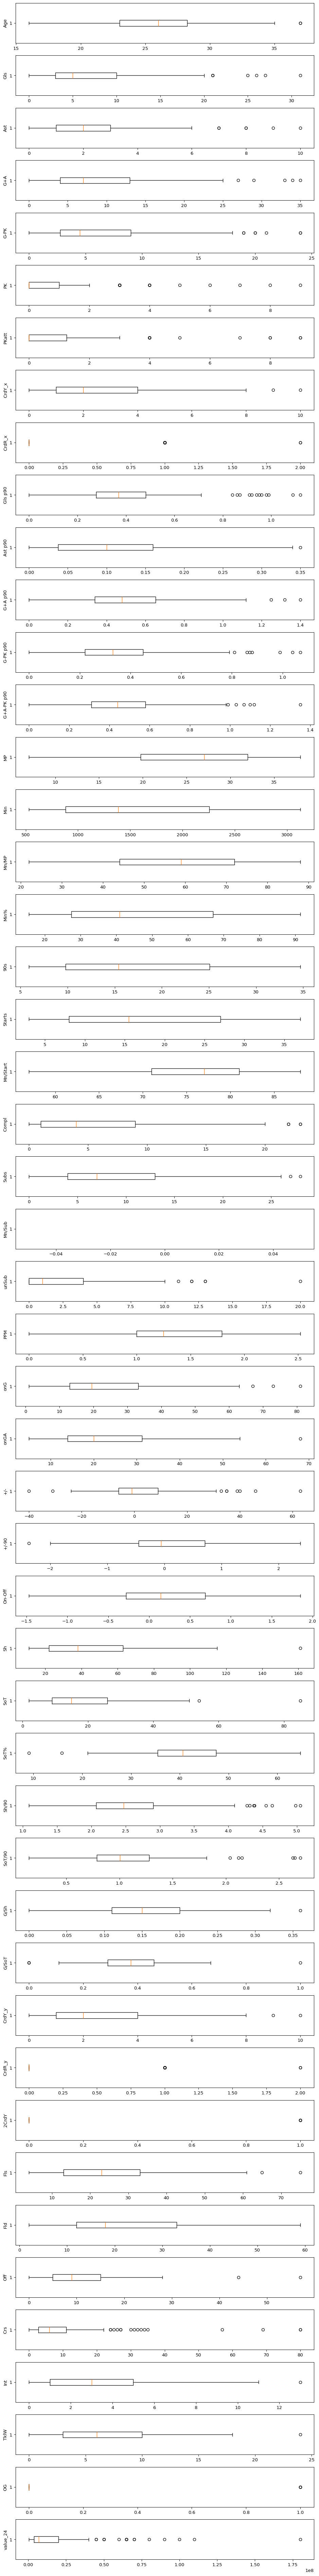

In [24]:
X_train.describe()

fig, axs = plt.subplots(len(X_train.columns), 1, figsize=(10, 80), dpi=95)
for i, col in enumerate(X_train.columns):
    axs[i].boxplot(X_train[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [25]:
# Use IQR to handle outliers
def detect_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - factor * IQR)
    upper = Q3 + factor * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return lower, upper

# lower, upper = detect_outliers_iqr(X_train, 'value_24')

# X_train['value_24'] = X_train['value_24'].clip(lower=lower, upper=upper)
# X_test['value_24'] = X_test['value_24'].clip(lower=lower, upper=upper)

for col in X_train:
    lower, upper = detect_outliers_iqr(X_train, col)

    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

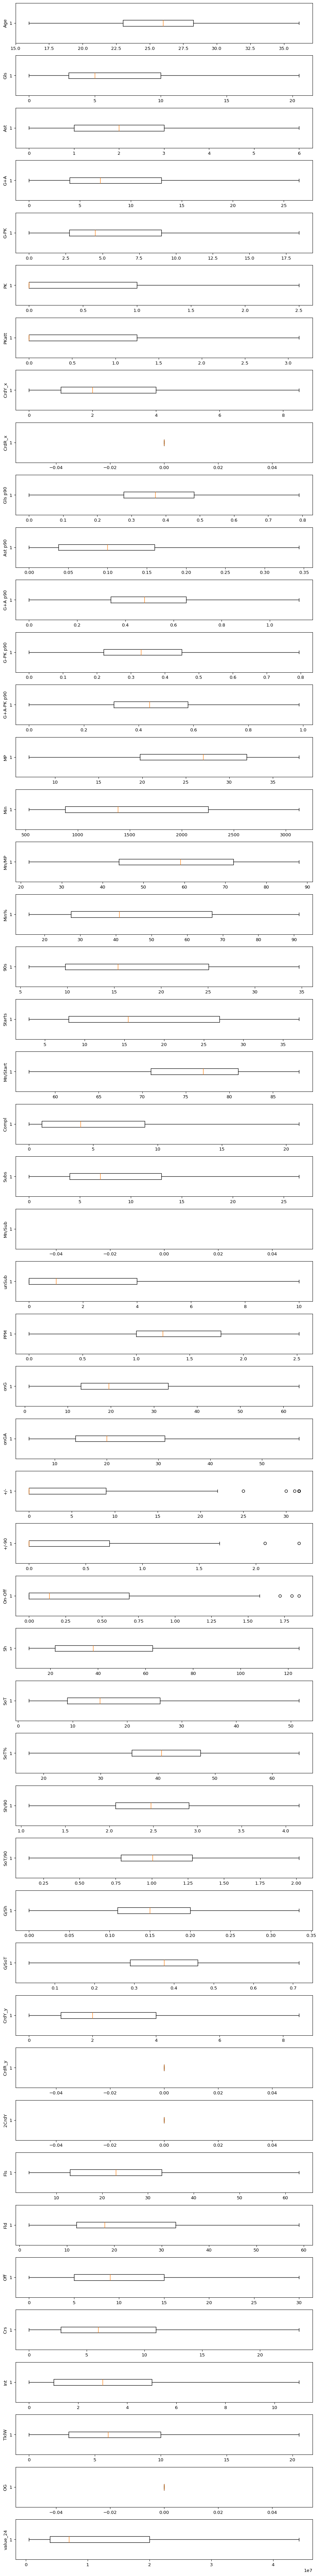

In [26]:
X_train.describe()

fig, axs = plt.subplots(len(X_train.columns), 1, figsize=(10, 80), dpi=95)
for i, col in enumerate(X_train.columns):
    axs[i].boxplot(X_train[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [27]:
X_test.columns

Index(['Age', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY_x', 'CrdR_x',
       'Gls p90', 'Ast p90', 'G+A p90', 'G-PK p90', 'G+A-PK p90', 'MP', 'Min',
       'Mn/MP', 'Min%', '90s', 'Starts', 'Mn/Start', 'Compl', 'Subs', 'Mn/Sub',
       'unSub', 'PPM', 'onG', 'onGA', '+/-', '+/-90', 'On-Off', 'Sh', 'SoT',
       'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'CrdY_y', 'CrdR_y', '2CrdY',
       'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW', 'OG', 'value_24'],
      dtype='str')

In [28]:
X_train.drop(columns=['CrdR_x', 'Mn/Sub', 'CrdR_y', '2CrdY', 'OG'], inplace=True)
X_test.drop(columns=['CrdR_x', 'Mn/Sub', 'CrdR_y', '2CrdY', 'OG'], inplace=True)

In [29]:
X_test.columns

Index(['Age', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY_x', 'Gls p90',
       'Ast p90', 'G+A p90', 'G-PK p90', 'G+A-PK p90', 'MP', 'Min', 'Mn/MP',
       'Min%', '90s', 'Starts', 'Mn/Start', 'Compl', 'Subs', 'unSub', 'PPM',
       'onG', 'onGA', '+/-', '+/-90', 'On-Off', 'Sh', 'SoT', 'SoT%', 'Sh/90',
       'SoT/90', 'G/Sh', 'G/SoT', 'CrdY_y', 'Fls', 'Fld', 'Off', 'Crs', 'Int',
       'TklW', 'value_24'],
      dtype='str')

In [42]:
train_data = X_train.copy()
train_data['value_25'] = y_train

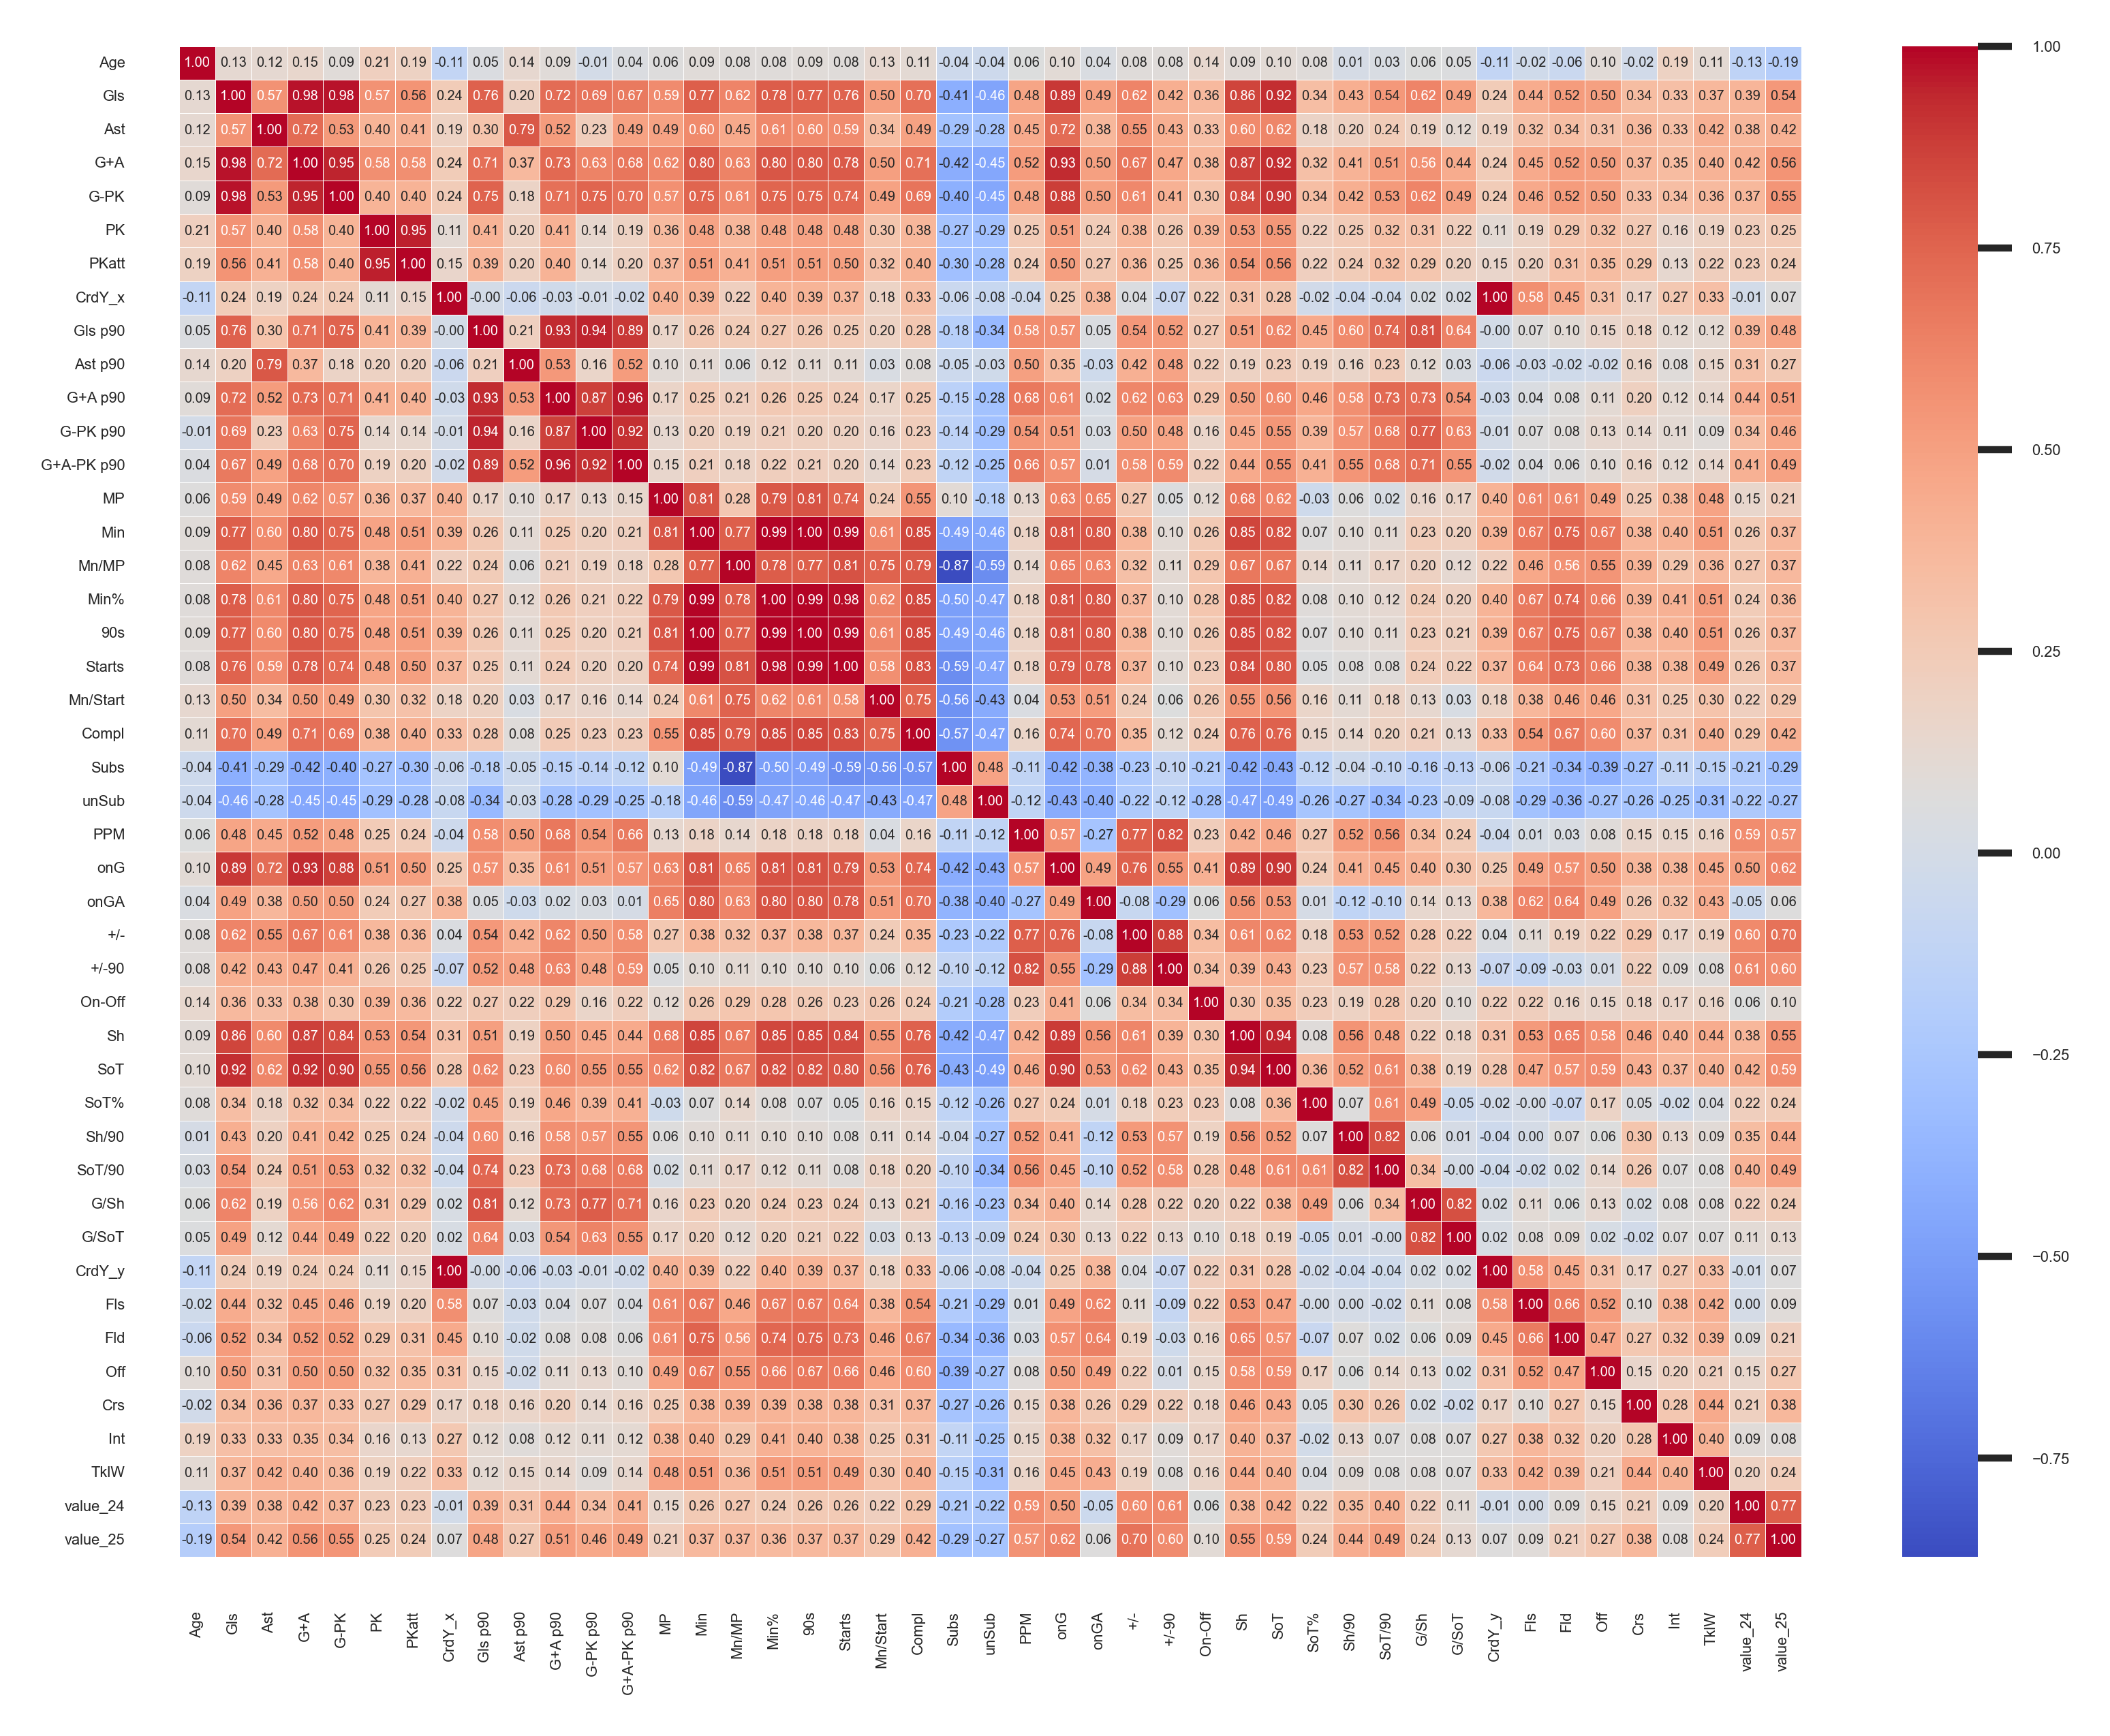

value_25      1.000000
value_24      0.772125
+/-           0.696050
onG           0.623499
+/-90         0.595922
SoT           0.585608
PPM           0.567959
G+A           0.557686
Sh            0.549672
G-PK          0.549528
Gls           0.537018
G+A p90       0.510112
SoT/90        0.492833
G+A-PK p90    0.491692
Gls p90       0.475196
G-PK p90      0.460990
Sh/90         0.436233
Compl         0.421065
Ast           0.418058
Crs           0.377127
Starts        0.370241
Mn/MP         0.369552
90s           0.368419
Min           0.368219
Min%          0.358358
Mn/Start      0.289084
Off           0.269654
Ast p90       0.265136
PK            0.251204
PKatt         0.243780
SoT%          0.243020
G/Sh          0.242597
TklW          0.239104
Fld           0.212714
MP            0.212297
G/SoT         0.125184
On-Off        0.104326
Fls           0.087530
Int           0.084115
CrdY_y        0.069060
CrdY_x        0.069060
onGA          0.064274
Age          -0.188662
unSub      

In [58]:
corr = train_data.corr()
plt.figure(dpi=600)
sns.set(font_scale=0.24)
res = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size":2.4}, linewidths=0.1)
plt.show()

print(corr['value_25'].sort_values(ascending=False))

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)